In [62]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import h5py 
import os
import pandas as pd
import matplotlib.colors as mcolors


In [63]:
dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
# sessName = 'BAYLORJH118_FOV5_2022_10_30_2022_12_01'
sessName = 'BAYLORJH118_FOV5_2022_10_05_2022_10_30'
# sessName = 'BAYLORJH123_FOV1_2022_10_01_2022_11_07'
# sessName = 'BAYLORJH134_FOV13_2023_04_29_2023_06_01'
# sessName = 'BAYLORJH118_FOV5_2022_10_30_2022_12_01'
fileName = sessName + '.npy'
# CD_0_BAYLORJH123_FOV1_2022_10_01_2022_11_07
filepath = dirpath + fileName

In [64]:
data = np.load(filepath, allow_pickle=True)
opto_sess1 = data['deconvolved'][0]
opto_sess2 = data['deconvolved'][1]


In [65]:
tsample   = 1.57
tdelay    = 2.87
tresponse = 4.17
dt        = 1/6
ntimestep = 47
tvec      = dt * np.arange(ntimestep)
tix_sample   = np.where(tvec > tsample)[0][0]
tix_delay    = np.where(tvec > tdelay)[0][0]
tix_response = np.where(tvec > tresponse)[0][0]

ncat, ncell = opto_sess1.shape
lickright = 0
lickleft  = 1

In [66]:
# concatenate all trials into one array
ntrials_1R = opto_sess1[lickright,0].shape[1]
ntrials_1L = opto_sess1[lickleft,0].shape[1]
ntrials_2R = opto_sess2[lickright,0].shape[1]
ntrials_2L = opto_sess2[lickleft,0].shape[1]
opto_1R_alltrials = np.zeros((ncell,ntimestep,ntrials_1R))
opto_1L_alltrials = np.zeros((ncell,ntimestep,ntrials_1L))
opto_2R_alltrials = np.zeros((ncell,ntimestep,ntrials_2R))
opto_2L_alltrials = np.zeros((ncell,ntimestep,ntrials_2L))
for cell in range(ncell):
    opto_1R_alltrials[cell] = opto_sess1[lickright,cell]
    opto_1L_alltrials[cell] = opto_sess1[lickleft,cell]
    opto_2R_alltrials[cell] = opto_sess2[lickright,cell]
    opto_2L_alltrials[cell] = opto_sess2[lickleft,cell]

In [67]:
# use only half of the trials to construct the CD
frac_train = 0.5
ntrain_trials_1R = int(ntrials_1R*frac_train)
ntrain_trials_1L = int(ntrials_1L*frac_train)
ntrain_trials_2R = int(ntrials_2R*frac_train)
ntrain_trials_2L = int(ntrials_2L*frac_train)
opto_1R = np.zeros((ncell,ntimestep))
opto_1L = np.zeros((ncell,ntimestep))
opto_2R = np.zeros((ncell,ntimestep))
opto_2L = np.zeros((ncell,ntimestep))
for cell in range(ncell):
    opto_1R[cell] = np.mean(opto_1R_alltrials[cell,:,:ntrain_trials_1R],axis=1)
    opto_1L[cell] = np.mean(opto_1L_alltrials[cell,:,:ntrain_trials_1L],axis=1)
    opto_2R[cell] = np.mean(opto_2R_alltrials[cell,:,:ntrain_trials_2R],axis=1)
    opto_2L[cell] = np.mean(opto_2L_alltrials[cell,:,:ntrain_trials_2L],axis=1)    
CD_sess1 = opto_1R - opto_1L
CD_sess2 = opto_2R - opto_2L
MR_sess1 = opto_1R + opto_1L
MR_sess2 = opto_2R + opto_2L

In [68]:
tix_delay_copy    = np.copy(tix_sample)
tix_response_copy = np.copy(tix_response)

CD_sess1_population = np.mean(CD_sess1[:,tix_delay:tix_response], axis=1)
CD_sess2_population = np.mean(CD_sess2[:,tix_delay:tix_response], axis=1)
CD_dotproduct       = np.inner(CD_sess1_population, CD_sess2_population) / (np.linalg.norm(CD_sess1_population) * np.linalg.norm(CD_sess2_population))
print('CD dot product: ', CD_dotproduct)


CD dot product:  0.7191276532007645


## Neural activity of neurons

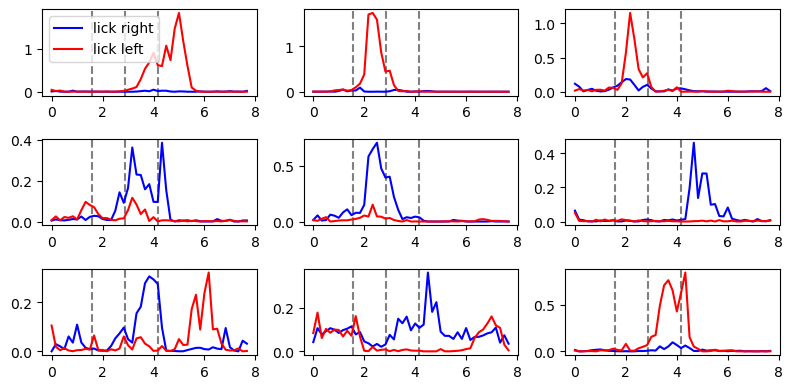

In [69]:
plt.figure(figsize=(8,4))
for ci in range(9):
    plt.subplot(3,3,ci+1)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    plt.plot(tvec, opto_1R[ci], c='b', label='lick right')
    plt.plot(tvec, opto_1L[ci], c='r', label='lick left')
    if ci == 0:
        plt.legend()
plt.tight_layout()

## Project population activity to CD

In [70]:
# project population activity to CD. Use only the test trials
opto_1R_testtrials = opto_1R_alltrials[:,:,ntrain_trials_1R:]
opto_1L_testtrials = opto_1L_alltrials[:,:,ntrain_trials_1L:]
opto_2R_testtrials = opto_2R_alltrials[:,:,ntrain_trials_2R:]
opto_2L_testtrials = opto_2L_alltrials[:,:,ntrain_trials_2L:]

proj_1R_CD1 = np.tensordot(CD_sess1_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD1 = np.tensordot(CD_sess1_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD2 = np.tensordot(CD_sess2_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD2 = np.tensordot(CD_sess2_population, opto_2L_testtrials, axes=(0,0))

proj_1R_CD2 = np.tensordot(CD_sess2_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD2 = np.tensordot(CD_sess2_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD1 = np.tensordot(CD_sess1_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD1 = np.tensordot(CD_sess1_population, opto_2L_testtrials, axes=(0,0))

print(proj_1R_CD1.shape, proj_1L_CD1.shape, proj_2R_CD2.shape, proj_2L_CD2.shape)


(47, 67) (47, 53) (47, 64) (47, 59)


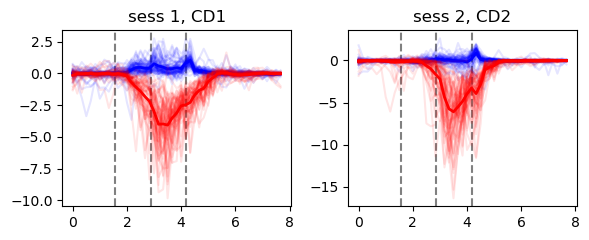

In [71]:
def plot_proj(tvec, proj_R, proj_L, ntest_trials_R, ntest_trials_L):
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    for trial in range(ntest_trials_R):
        plt.plot(tvec, proj_R[:,trial], c='b', alpha=0.1)
    plt.plot(tvec, np.mean(proj_R,axis=1), c='b', lw=2)
    for trial in range(ntest_trials_L):
        plt.plot(tvec, proj_L[:,trial], c='r', alpha=0.1)
    plt.plot(tvec, np.mean(proj_L,axis=1), c='r', lw=2)
    
ntest_trials_1R = ntrials_1R - ntrain_trials_1R
ntest_trials_1L = ntrials_1L - ntrain_trials_1L
ntest_trials_2R = ntrials_2R - ntrain_trials_2R
ntest_trials_2L = ntrials_2L - ntrain_trials_2L

plt.figure(figsize=(6,2.5))
plt.subplot(1,2,1)
plt.title('sess 1, CD1')
proj_R = proj_1R_CD1
proj_L = proj_1L_CD1
plot_proj(tvec, proj_R, proj_L, ntest_trials_1R, ntest_trials_1L)

plt.subplot(1,2,2)
plt.title('sess 2, CD2')
proj_R = proj_2R_CD2
proj_L = proj_2L_CD2
plot_proj(tvec, proj_R, proj_L, ntest_trials_2R, ntest_trials_2L)
plt.tight_layout()


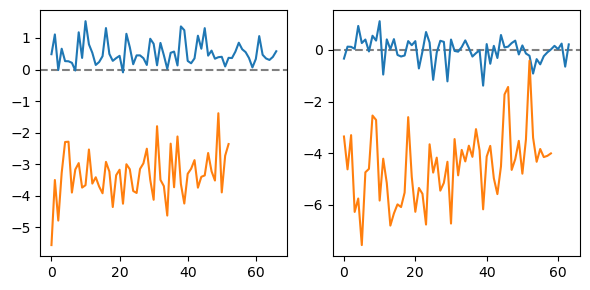

In [76]:
decision_1R = np.mean(proj_1R_CD1[tix_delay:tix_response,:],axis=0)
decision_1L = np.mean(proj_1L_CD1[tix_delay:tix_response,:],axis=0)
decision_2R = np.mean(proj_2R_CD2[tix_delay:tix_response,:],axis=0)
decision_2L = np.mean(proj_2L_CD2[tix_delay:tix_response,:],axis=0)

plt.figure(figsize=(6,3))
plt.subplot(121)
plt.axhline(0, color='gray', linestyle='--')
plt.plot(decision_1R)
plt.plot(decision_1L)

plt.subplot(122)
plt.axhline(0, color='gray', linestyle='--')
plt.plot(decision_2R)
plt.plot(decision_2L)
plt.tight_layout()


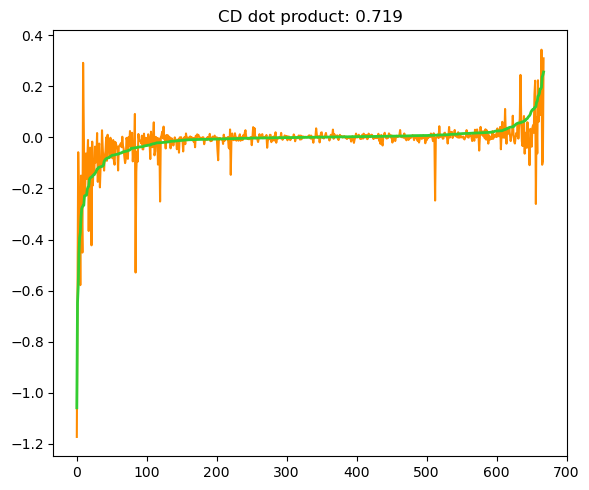

In [79]:
neuron_sorted_by_CD_sess1 = np.argsort(CD_sess1_population)
neuron_sorted_by_CD_sess2 = np.argsort(CD_sess2_population)
plt.figure(figsize=(6,5))
plt.plot(CD_sess2_population[neuron_sorted_by_CD_sess1], c='darkorange')
# plt.plot(CD_sess2_population[neuron_sorted_by_CD_sess2], c='k', linestyle='--')
plt.plot(CD_sess1_population[neuron_sorted_by_CD_sess1], c='limegreen', lw=2)
plt.title('CD dot product: ' + str(np.round(CD_dotproduct,decimals=3)))
plt.tight_layout()


In [7]:
import numpy as np
np.sqrt(0.26*0.74/120)


0.040041644987854